In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samxsam/human-cognitive-performance-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-cognitive-performance-analysis' dataset.
Path to dataset files: /kaggle/input/human-cognitive-performance-analysis


In [6]:
df = pd.read_csv('/kaggle/input/human-cognitive-performance-analysis/human_cognitive_performance.csv')

print(" Dimenions du dataset:")
print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

print("\n Infos du dataset:")
print(df.info())

 Dimenions de la dataset:
Shape: (80000, 13) (Rows: 80000, Columns: 13)

 Infos de la dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB

In [10]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


En examinant le df.head() on comprend que la variable AI_predicted_Score avait pour but de prédire Cognitive_Score. En effet les valeurs numériques des deux variables sont très proches à chaque ligne.

Partie 1 : Preprocessing

In [16]:
print('Data types:')
print(df.dtypes)

missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("\n Il n'y a pas de valeurs manquantes")

if (df.isna().values.any()==0) :
  print("\n Il n'y a pas non plus de Nan")

Data types:
User_ID                object
Age                     int64
Gender                 object
Sleep_Duration        float64
Stress_Level            int64
Diet_Type              object
Daily_Screen_Time     float64
Exercise_Frequency     object
Caffeine_Intake         int64
Reaction_Time         float64
Memory_Test_Score       int64
Cognitive_Score       float64
AI_Predicted_Score    float64
dtype: object
Series([], dtype: int64)

 Il n'y a pas de valeurs manquantes

 Il n'y a pas non plus de Nan


On choisit Cognitive_Score comme target d'après la remarque qu'on a fait précédemment.

Pour nos features, on choisit :  

1.  Age
2.    Gender
3. Sleep_Duration
4. Stress_Level
5. Diet_Type
6. Daily_Screen_Time
7. Exercise_Frequency
8. Caffeine_Intake.

  Ce sont des variables explicatives représentant la physiologie, l'hygiène de vie et la charge mentale des sujets.

  User_ID est un indentifiant, donc ne répresente aucune info prédictive, donc elle est à exclure.
  D'autre part, AI_Predicted_Score est déjà un output d'un modèle IA donc on l'exclut pour éviter les dataleakage.
  
  De même, Reaction_Time et Memory_Test_Score sont à exclure des features, car ce sont des variables trop liées à notre target.


In [17]:
y = df["Cognitive_Score"]
X = df.drop(columns=[
    "Cognitive_Score",
    "User_ID",
    "Memory_Test_Score",
    "Reaction_Time",
    "AI_Predicted_Score"
])


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

On doit à présent séparer les features numériques des features catégorielles.

In [19]:
num_features = [
    "Age",
    "Sleep_Duration",
    "Stress_Level",
    "Daily_Screen_Time",
    "Caffeine_Intake"
]

cat_features = [
    "Gender",
    "Diet_Type",
    "Exercise_Frequency"
]

On construit donc le prépropcesseur.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

Partie 2 : Modélisation

Modèle A : Régression linéaire

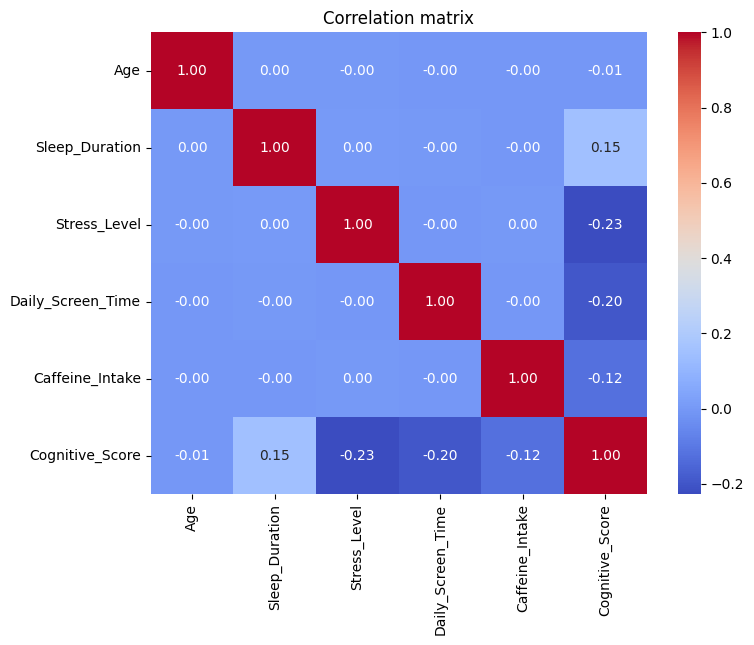

In [26]:
num_cols = [
    "Age",
    "Sleep_Duration",
    "Stress_Level",
    "Daily_Screen_Time",
    "Caffeine_Intake",
    "Cognitive_Score"
]

corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

La matrice de corrélation met en évidence des relations linéaires faibles entre certaines features (durée de sommeil, niveau de stress, temps d’écran) et le score cognitif.
Cela suggère l’existence de relations non linéaires, ce qui suggère l'utilisation de modèle coemme les Random forest et les réseaux de neurones.

Nous allons tout de même commencer par un modèle de regression linéaire puisque notre target est une variable continue. C'est un modèle simple qui nous servira de référence pour la suite.

In [21]:
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

lin_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Sleep_Duration',
                                                   'Stress_Level',
                                                   'Daily_Screen_Time',
                                                   'Caffeine_Intake']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Diet_Type',
                                                   'Exercise_Frequency'])])),
                ('model', LinearRegression())])

In [ ]:
On peut alors évaluer notre modèle